In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import networkx as nx
import json, os, warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')
print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
np.random.seed(42)
n = 250

products = ['Laptop', 'TV', 'Smartphone', 'Tablet', 'Headphones', 'Camera']
cities   = ['London', 'Manchester', 'Birmingham', 'Edinburgh', 'Bristol']
stores   = ['14 Oxford St', '8 Canary Wharf', '22 Kings Road', '5 Deansgate', '10 Broad St']
genders  = ['Male', 'Female']
payments = ['Credit Card', 'Cash', 'PayPal', 'Debit Card']
dates    = pd.date_range('2022-01-01', '2024-12-31', periods=n)

records = []
for i in range(n):
    price = round(np.random.uniform(50, 2000), 2)
    if i % 20 == 0:
        price = 'REFUNDED'
    elif i % 30 == 0:
        price = '$PENDING'
    city = np.random.choice(cities) if i % 10 != 0 else None

    records.append({
        "transaction_id": f"TXN-{i+1:04d}",
        "timestamp": str(dates[i].date()),
        "meta_info": {"city": city, "store": np.random.choice(stores)},
        "basket": {
            "product": np.random.choice(products),
            "quantity": int(np.random.randint(1, 10)),
            "unit_price": price
        },
        "customer": {
            "gender": np.random.choice(genders),
            "age": int(np.random.randint(18, 70)),
            "payment": np.random.choice(payments)
        }
    })

records += records[:25]  # inject 25 duplicates

os.makedirs('data_lake', exist_ok=True)
with open('data_lake/source_a.json', 'w') as f:
    json.dump(records, f, indent=2)

print(f"Source A saved: {len(records)} records (250 base + 25 duplicates)")
print("Noise injected: REFUNDED, $PENDING in price | null city values | nested structure")

Source A saved: 275 records (250 base + 25 duplicates)
Noise injected: REFUNDED, $PENDING in price | null city values | nested structure


In [5]:
np.random.seed(99)
n = 250

df_b = pd.DataFrame({
    'TRANSACTION_ID':  [f'POS-{i+1:04d}' for i in range(n)],
    'DATE':            pd.date_range('2022-01-01', '2024-12-31', periods=n).astype(str),
    'CITY':            np.random.choice(cities, n),
    'STORE':           np.random.choice(stores, n),
    'PRODUCT':         np.random.choice(products, n),
    'UNITS':           [int(np.random.randint(1,10)) if i % 15 != 0
                        else (None if i % 30 != 0 else 'QTY_ERR') for i in range(n)],
    'PRICE_PER_UNIT':  [round(np.random.uniform(50,2000),2) if i % 25 != 0
                        else round(-np.random.uniform(10,200),2) for i in range(n)],
    'CUSTOMER_GENDER': np.random.choice(genders, n),
    'CUSTOMER_AGE':    np.random.randint(18, 70, n),
    'PAYMENT':         np.random.choice(payments, n)
})

df_b.to_csv('data_lake/source_b.csv', index=False)
print(f"Source B saved: {df_b.shape}")
print("Noise injected: negative prices | None quantity | QTY_ERR strings")
print(df_b.head())

Source B saved: (250, 10)
Noise injected: negative prices | None quantity | QTY_ERR strings
  TRANSACTION_ID                           DATE        CITY          STORE  \
0       POS-0001  2022-01-01 00:00:00.000000000  Manchester    5 Deansgate   
1       POS-0002  2022-01-05 09:32:31.807228915   Edinburgh    5 Deansgate   
2       POS-0003  2022-01-09 19:05:03.614457831  Manchester  22 Kings Road   
3       POS-0004  2022-01-14 04:37:35.421686747      London  22 Kings Road   
4       POS-0005  2022-01-18 14:10:07.228915662  Manchester  22 Kings Road   

      PRODUCT    UNITS  PRICE_PER_UNIT CUSTOMER_GENDER  CUSTOMER_AGE  \
0          TV  QTY_ERR         -103.04            Male            53   
1          TV        6         1128.82            Male            23   
2  Smartphone        4         1633.80          Female            40   
3          TV        5          616.61          Female            28   
4      Camera        4         1773.73          Female            60   

      

In [7]:
with open('data_lake/source_a.json') as f:
    raw = json.load(f)

rows = []
for r in raw:
    rows.append({
        'transaction_id': r['transaction_id'],
        'timestamp':      r['timestamp'],
        'city':           r['meta_info']['city'],
        'store':          r['meta_info']['store'],
        'product':        r['basket']['product'],
        'quantity':       r['basket']['quantity'],
        'unit_price':     r['basket']['unit_price'],
        'gender':         r['customer']['gender'],
        'age':            r['customer']['age'],
        'payment':        r['customer']['payment']
    })

df_a = pd.DataFrame(rows)
print("=== Shape:", df_a.shape, "===")
print("\n--- .info() ---")
df_a.info()
print("\n--- .describe() ---")
print(df_a.describe(include='all'))
print("\n--- Missing Values ---")
print(df_a.isnull().sum())

=== Shape: (275, 10) ===

--- .info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  275 non-null    object
 1   timestamp       275 non-null    object
 2   city            247 non-null    object
 3   store           275 non-null    object
 4   product         275 non-null    object
 5   quantity        275 non-null    int64 
 6   unit_price      275 non-null    object
 7   gender          275 non-null    object
 8   age             275 non-null    int64 
 9   payment         275 non-null    object
dtypes: int64(2), object(8)
memory usage: 21.6+ KB

--- .describe() ---
       transaction_id   timestamp     city         store product    quantity  \
count             275         275      247           275     275  275.000000   
unique            250         250        5             5       6         NaN   
top          

In [8]:
df_b_raw = pd.read_csv('data_lake/source_b.csv')
print("=== Shape:", df_b_raw.shape, "===")
print("\n--- .info() ---")
df_b_raw.info()
print("\n--- .describe() ---")
print(df_b_raw.describe(include='all'))
print("\n--- Missing Values ---")
print(df_b_raw.isnull().sum())

=== Shape: (250, 10) ===

--- .info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TRANSACTION_ID   250 non-null    object 
 1   DATE             250 non-null    object 
 2   CITY             250 non-null    object 
 3   STORE            250 non-null    object 
 4   PRODUCT          250 non-null    object 
 5   UNITS            242 non-null    object 
 6   PRICE_PER_UNIT   250 non-null    float64
 7   CUSTOMER_GENDER  250 non-null    object 
 8   CUSTOMER_AGE     250 non-null    int64  
 9   PAYMENT          250 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 19.7+ KB

--- .describe() ---
       TRANSACTION_ID                           DATE       CITY        STORE  \
count             250                            250        250          250   
unique            250                            250     

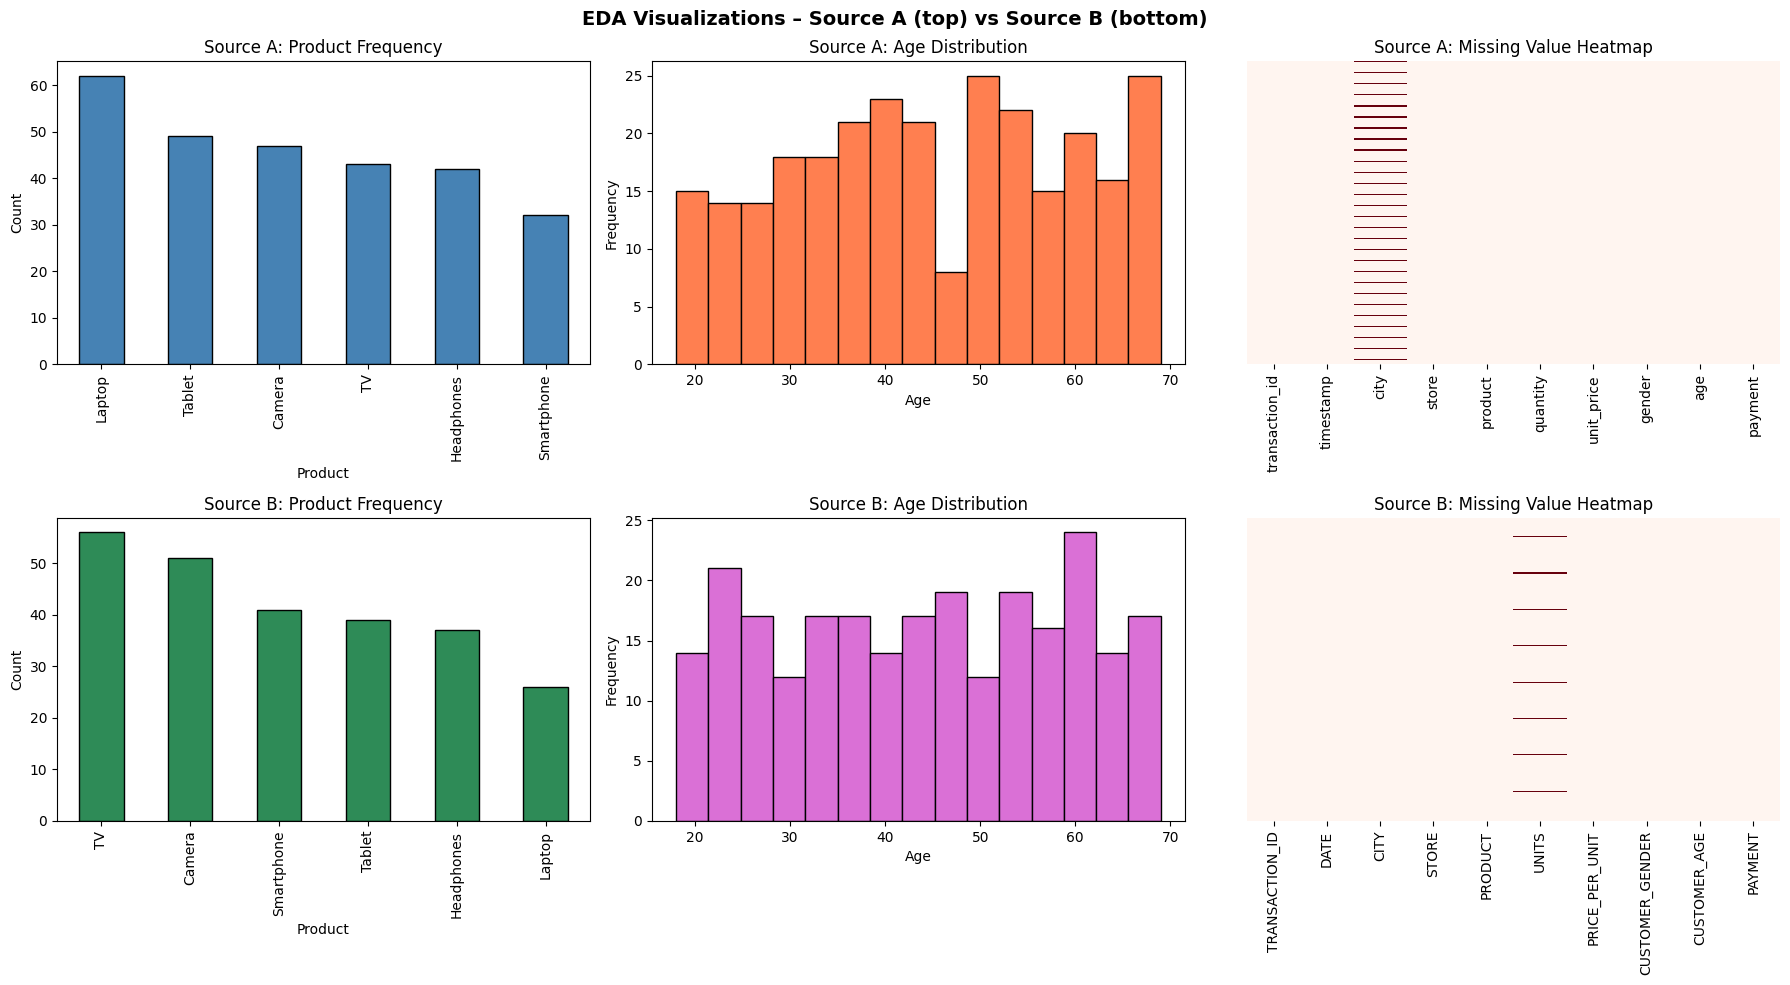

EDA visualization saved.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA Visualizations – Source A (top) vs Source B (bottom)', fontsize=14, fontweight='bold')

# Source A
df_a['product'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Source A: Product Frequency')
axes[0,0].set_xlabel('Product'); axes[0,0].set_ylabel('Count')

axes[0,1].hist(df_a['age'].dropna(), bins=15, color='coral', edgecolor='black')
axes[0,1].set_title('Source A: Age Distribution')
axes[0,1].set_xlabel('Age'); axes[0,1].set_ylabel('Frequency')

sns.heatmap(df_a.isnull(), cbar=False, ax=axes[0,2], yticklabels=False, cmap='Reds')
axes[0,2].set_title('Source A: Missing Value Heatmap')

# Source B
df_b_raw['PRODUCT'].value_counts().plot(kind='bar', ax=axes[1,0], color='seagreen', edgecolor='black')
axes[1,0].set_title('Source B: Product Frequency')
axes[1,0].set_xlabel('Product'); axes[1,0].set_ylabel('Count')

axes[1,1].hist(df_b_raw['CUSTOMER_AGE'].dropna(), bins=15, color='orchid', edgecolor='black')
axes[1,1].set_title('Source B: Age Distribution')
axes[1,1].set_xlabel('Age'); axes[1,1].set_ylabel('Frequency')

sns.heatmap(df_b_raw.isnull(), cbar=False, ax=axes[1,2], yticklabels=False, cmap='Reds')
axes[1,2].set_title('Source B: Missing Value Heatmap')

plt.tight_layout()
plt.savefig('eda_visualisations.png', dpi=150)
plt.show()
print("EDA visualization saved.")

In [10]:
# --- Clean Source A ---
df_a_clean = df_a.drop_duplicates(subset='transaction_id')
df_a_clean = df_a_clean[~df_a_clean['unit_price'].isin(['REFUNDED', '$PENDING'])]
df_a_clean['unit_price'] = df_a_clean['unit_price'].astype(float)
df_a_clean = df_a_clean.dropna(subset=['city'])
df_a_clean['date'] = pd.to_datetime(df_a_clean['timestamp'])

# --- Clean Source B ---
df_b_clean = df_b_raw.copy()
df_b_clean = df_b_clean[
    df_b_clean['UNITS'].apply(lambda x: str(x).replace('.','',1).isdigit() if pd.notna(x) else False)
]
df_b_clean['UNITS'] = df_b_clean['UNITS'].astype(float)
df_b_clean = df_b_clean[df_b_clean['PRICE_PER_UNIT'] > 0]
df_b_clean.rename(columns={
    'TRANSACTION_ID':'transaction_id', 'DATE':'timestamp', 'CITY':'city',
    'STORE':'store', 'PRODUCT':'product', 'UNITS':'quantity',
    'PRICE_PER_UNIT':'unit_price', 'CUSTOMER_GENDER':'gender',
    'CUSTOMER_AGE':'age', 'PAYMENT':'payment'
}, inplace=True)
df_b_clean['date'] = pd.to_datetime(df_b_clean['timestamp'])

# --- Merge ---
df_merged = pd.concat([df_a_clean, df_b_clean], ignore_index=True)
print("Source A clean shape:", df_a_clean.shape)
print("Source B clean shape:", df_b_clean.shape)
print("Merged shape:", df_merged.shape)
print(df_merged.head())

Source A clean shape: (225, 11)
Source B clean shape: (227, 11)
Merged shape: (452, 11)
  transaction_id   timestamp        city           store     product  \
0       TXN-0002  2022-01-05  Birmingham   22 Kings Road  Headphones   
1       TXN-0003  2022-01-09  Manchester     5 Deansgate      Camera   
2       TXN-0004  2022-01-14     Bristol     5 Deansgate      Laptop   
3       TXN-0005  2022-01-18  Birmingham     5 Deansgate      Tablet   
4       TXN-0006  2022-01-22      London  8 Canary Wharf      Tablet   

   quantity  unit_price  gender  age      payment       date  
0       4.0      919.37  Female   41       PayPal 2022-01-05  
1       6.0       90.14  Female   38  Credit Card 2022-01-09  
2       1.0      643.27    Male   59   Debit Card 2022-01-14  
3       9.0      619.68    Male   54       PayPal 2022-01-18  
4       9.0     1376.60  Female   31         Cash 2022-01-22  


In [11]:
df_merged['total_sales'] = df_merged['quantity'] * df_merged['unit_price']

df_merged['season'] = df_merged['date'].dt.month.map({
    1:'Q1',2:'Q1',3:'Q1',4:'Q2',5:'Q2',6:'Q2',
    7:'Q3',8:'Q3',9:'Q3',10:'Q4',11:'Q4',12:'Q4'
})

df_merged['age_group'] = pd.cut(df_merged['age'],
    bins=[0,25,40,55,100], labels=['Youth','Adult','Middle-Aged','Senior'])

df_merged['price_tier'] = pd.cut(df_merged['unit_price'],
    bins=[0,200,700,1500,9999], labels=['Budget','Mid-Range','Premium','Luxury'])

df_merged['revenue_band'] = pd.cut(df_merged['total_sales'],
    bins=[0,500,2000,10000,999999], labels=['Low','Medium','High','Very High'])

df_merged['year'] = df_merged['date'].dt.year

os.makedirs('data_warehouse', exist_ok=True)
df_merged.to_csv('data_warehouse/warehouse.csv', index=False)

print("Feature engineering complete. New columns added:")
print(df_merged[['product','city','season','age_group','price_tier','revenue_band','total_sales','year']].head(10))

Feature engineering complete. New columns added:
      product        city season    age_group price_tier revenue_band  \
0  Headphones  Birmingham     Q1  Middle-Aged    Premium         High   
1      Camera  Manchester     Q1        Adult     Budget       Medium   
2      Laptop     Bristol     Q1       Senior  Mid-Range       Medium   
3      Tablet  Birmingham     Q1  Middle-Aged  Mid-Range         High   
4      Tablet      London     Q1        Adult    Premium    Very High   
5          TV  Manchester     Q1       Senior    Premium         High   
6      Camera     Bristol     Q1       Senior  Mid-Range          Low   
7      Camera  Manchester     Q1       Senior     Luxury         High   
8      Laptop   Edinburgh     Q1        Adult    Premium         High   
9      Laptop     Bristol     Q1  Middle-Aged  Mid-Range         High   

   total_sales  year  
0      3677.48  2022  
1       540.84  2022  
2       643.27  2022  
3      5577.12  2022  
4     12389.40  2022  
5      32

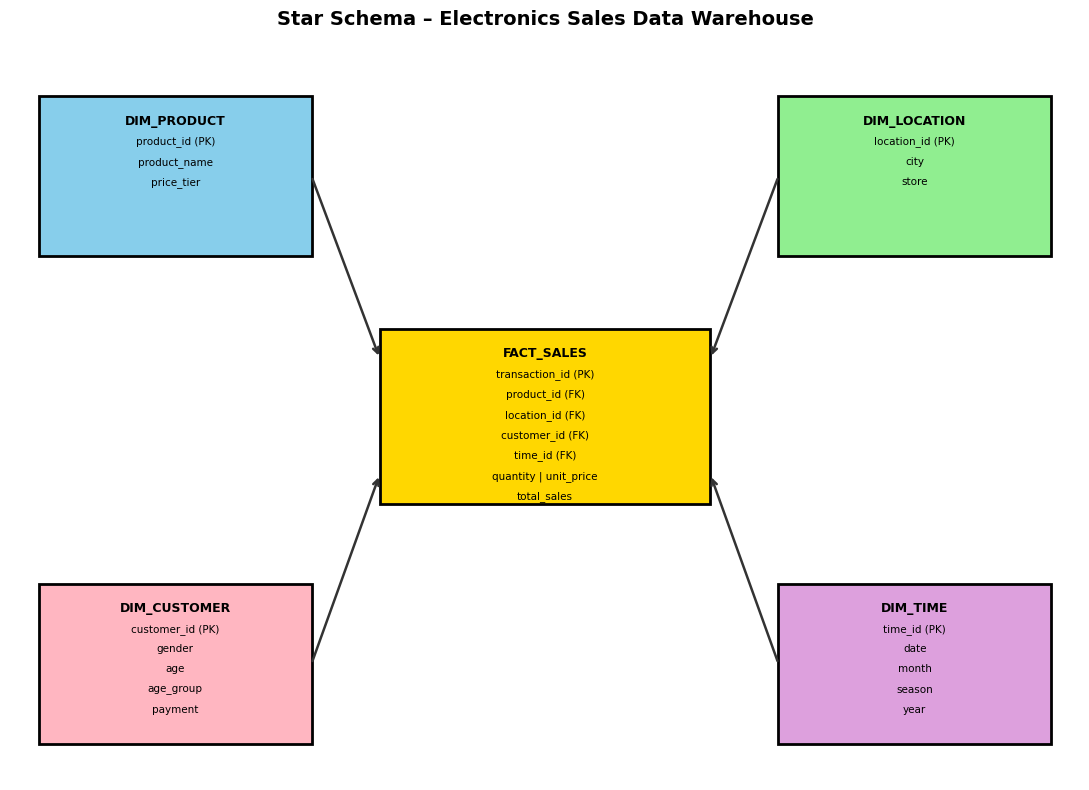

Star schema saved.


In [12]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_xlim(0, 11); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('Star Schema – Electronics Sales Data Warehouse', fontsize=14, fontweight='bold', pad=20)

def draw_box(ax, x, y, w, h, title, lines, fc):
    ax.add_patch(plt.Rectangle((x,y), w, h, fc=fc, ec='black', lw=2, zorder=2))
    ax.text(x+w/2, y+h-0.25, title, ha='center', va='top', fontsize=9, fontweight='bold')
    for i, line in enumerate(lines):
        ax.text(x+w/2, y+h-0.55-(i*0.28), line, ha='center', va='top', fontsize=7.5)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=1.8), zorder=3)

# Fact table center
draw_box(ax, 3.8, 3.8, 3.4, 2.4, 'FACT_SALES',
         ['transaction_id (PK)','product_id (FK)','location_id (FK)',
          'customer_id (FK)','time_id (FK)','quantity | unit_price','total_sales'], '#FFD700')

# Dimensions
draw_box(ax, 0.3, 7.2, 2.8, 2.2, 'DIM_PRODUCT',
         ['product_id (PK)','product_name','price_tier'], '#87CEEB')
draw_box(ax, 7.9, 7.2, 2.8, 2.2, 'DIM_LOCATION',
         ['location_id (PK)','city','store'], '#90EE90')
draw_box(ax, 0.3, 0.5, 2.8, 2.2, 'DIM_CUSTOMER',
         ['customer_id (PK)','gender','age','age_group','payment'], '#FFB6C1')
draw_box(ax, 7.9, 0.5, 2.8, 2.2, 'DIM_TIME',
         ['time_id (PK)','date','month','season','year'], '#DDA0DD')

# Arrows from dimensions to fact
draw_arrow(ax, 3.1, 8.3, 3.8, 5.8)
draw_arrow(ax, 7.9, 8.3, 7.2, 5.8)
draw_arrow(ax, 3.1, 1.6, 3.8, 4.2)
draw_arrow(ax, 7.9, 1.6, 7.2, 4.2)

plt.tight_layout()
plt.savefig('star_schema.png', dpi=150, bbox_inches='tight')
plt.show()
print("Star schema saved.")

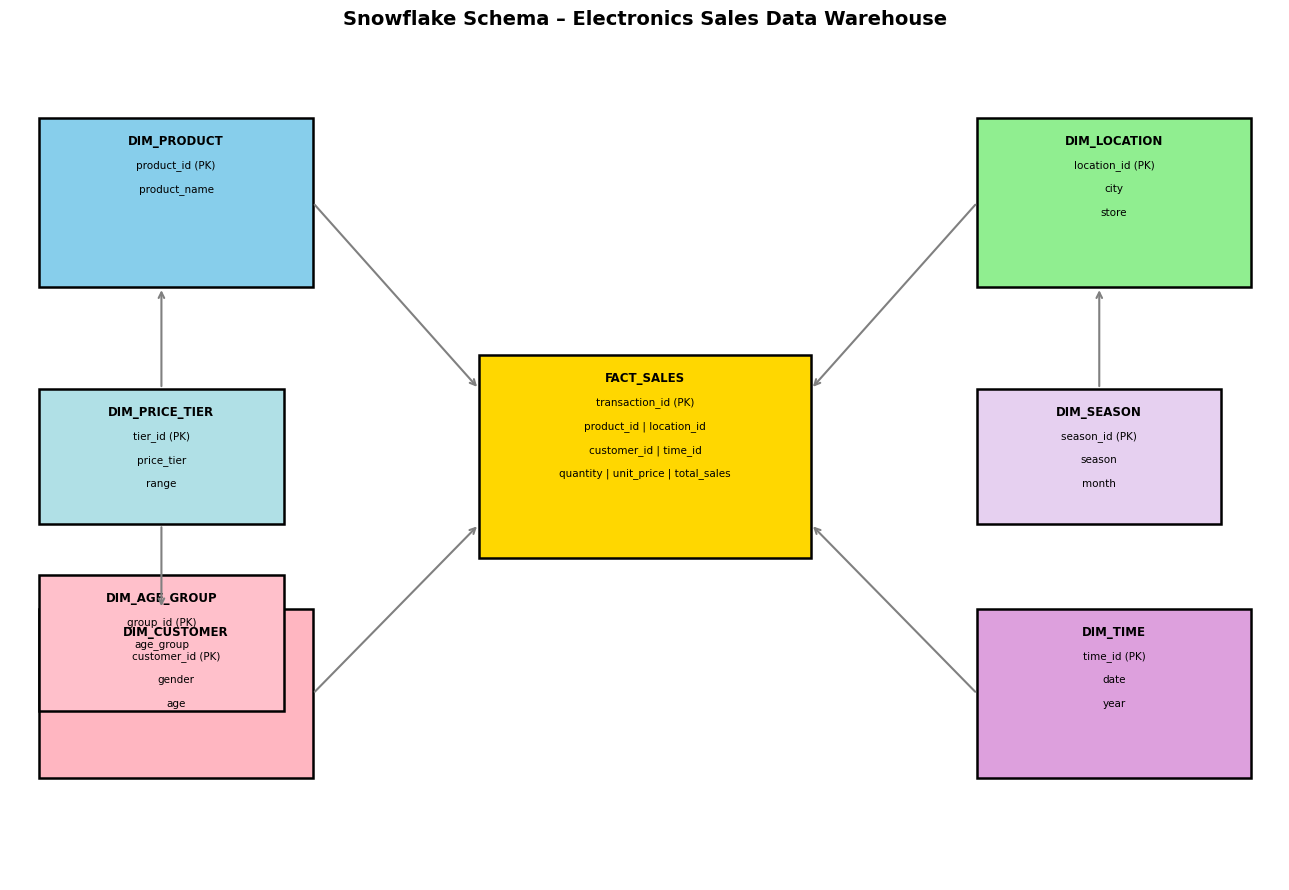

Snowflake schema saved.


In [13]:
fig, ax = plt.subplots(figsize=(13, 9))
ax.set_xlim(0,13); ax.set_ylim(0,10); ax.axis('off')
ax.set_title('Snowflake Schema – Electronics Sales Data Warehouse', fontsize=14, fontweight='bold')

def sbox(ax, x, y, w, h, title, lines, fc):
    ax.add_patch(plt.Rectangle((x,y), w, h, fc=fc, ec='black', lw=1.8, zorder=2))
    ax.text(x+w/2, y+h-0.2, title, ha='center', va='top', fontsize=8.5, fontweight='bold')
    for i, l in enumerate(lines):
        ax.text(x+w/2, y+h-0.5-(i*0.28), l, ha='center', va='top', fontsize=7.5)

def sarrow(ax, x1,y1,x2,y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), zorder=3)

# Fact (center)
sbox(ax, 4.8, 3.8, 3.4, 2.4, 'FACT_SALES',
     ['transaction_id (PK)','product_id | location_id','customer_id | time_id',
      'quantity | unit_price | total_sales'], '#FFD700')

# Main dimensions
sbox(ax, 0.3, 7.0, 2.8, 2.0, 'DIM_PRODUCT', ['product_id (PK)','product_name'], '#87CEEB')
sbox(ax, 9.9, 7.0, 2.8, 2.0, 'DIM_LOCATION', ['location_id (PK)','city','store'], '#90EE90')
sbox(ax, 0.3, 1.2, 2.8, 2.0, 'DIM_CUSTOMER', ['customer_id (PK)','gender','age'], '#FFB6C1')
sbox(ax, 9.9, 1.2, 2.8, 2.0, 'DIM_TIME', ['time_id (PK)','date','year'], '#DDA0DD')

# Sub-dimensions
sbox(ax, 0.3, 4.2, 2.5, 1.6, 'DIM_PRICE_TIER', ['tier_id (PK)','price_tier','range'], '#B0E0E6')
sbox(ax, 0.3, 4.2-2.2, 2.5, 1.6, 'DIM_AGE_GROUP', ['group_id (PK)','age_group'], '#FFC0CB')
sbox(ax, 9.9, 4.2, 2.5, 1.6, 'DIM_SEASON', ['season_id (PK)','season','month'], '#E6D0F0')

# Arrows: dim → fact
sarrow(ax, 3.1, 8.0, 4.8, 5.8)
sarrow(ax, 9.9, 8.0, 8.2, 5.8)
sarrow(ax, 3.1, 2.2, 4.8, 4.2)
sarrow(ax, 9.9, 2.2, 8.2, 4.2)

# Arrows: sub-dim → dim
sarrow(ax, 1.55, 5.8, 1.55, 7.0)
sarrow(ax, 1.55, 4.2, 1.55, 3.2)
sarrow(ax, 11.15, 5.8, 11.15, 7.0)

plt.tight_layout()
plt.savefig('snowflake_schema.png', dpi=150, bbox_inches='tight')
plt.show()
print("Snowflake schema saved.")

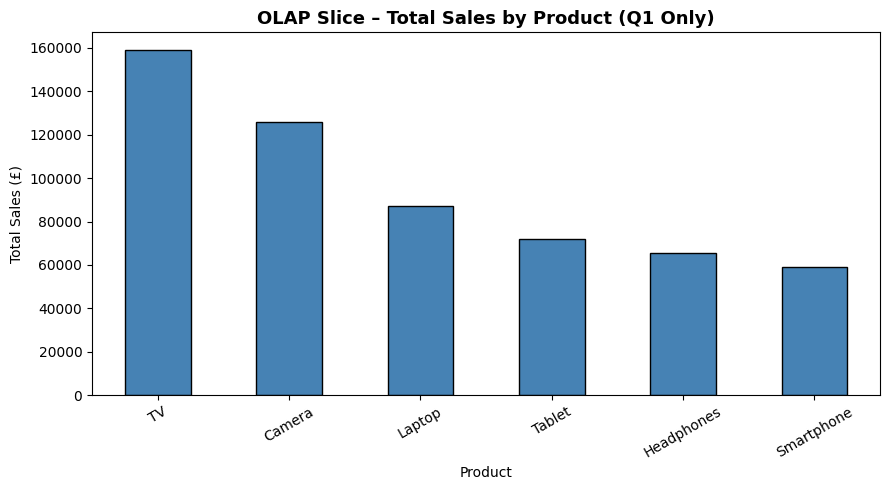

Slice Q1 records: 113


In [14]:
slice_q1 = df_merged[df_merged['season'] == 'Q1']

slice_q1.groupby('product')['total_sales'].sum().sort_values(ascending=False).plot(
    kind='bar', color='steelblue', edgecolor='black', figsize=(9, 5))
plt.title('OLAP Slice – Total Sales by Product (Q1 Only)', fontsize=13, fontweight='bold')
plt.ylabel('Total Sales (£)'); plt.xlabel('Product')
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig('slice_q1.png', dpi=150)
plt.show()
print("Slice Q1 records:", slice_q1.shape[0])

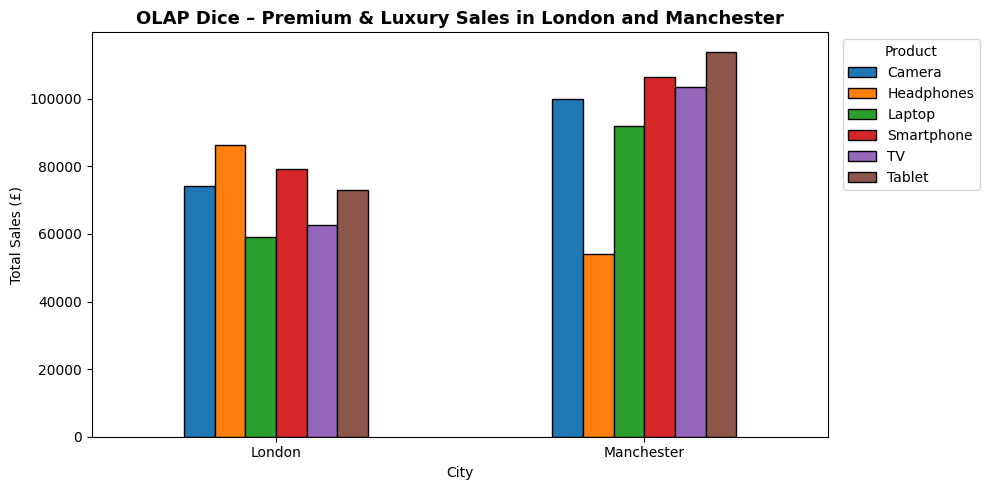

Dice records: 141


In [15]:
dice = df_merged[
    (df_merged['price_tier'].isin(['Premium', 'Luxury'])) &
    (df_merged['city'].isin(['London', 'Manchester']))
]

dice.groupby(['city','product'])['total_sales'].sum().unstack().plot(
    kind='bar', figsize=(10, 5), edgecolor='black')
plt.title('OLAP Dice – Premium & Luxury Sales in London and Manchester', fontsize=13, fontweight='bold')
plt.ylabel('Total Sales (£)'); plt.xlabel('City')
plt.xticks(rotation=0); plt.legend(title='Product', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('dice_view.png', dpi=150)
plt.show()
print("Dice records:", dice.shape[0])

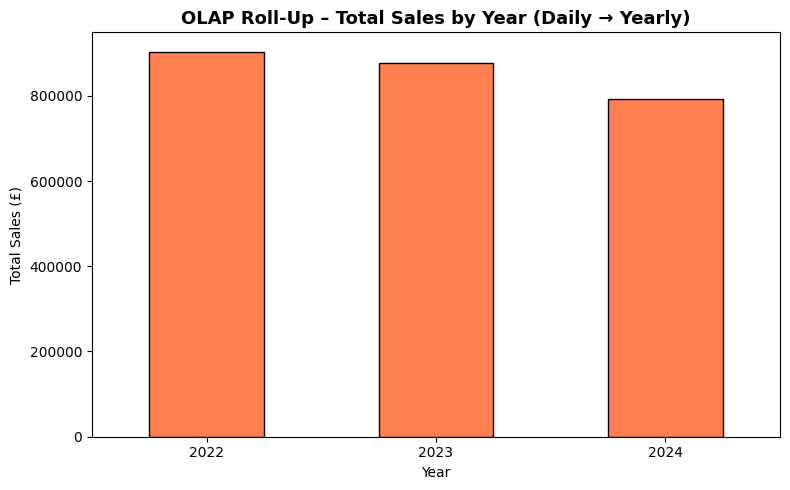

 year  total_sales
 2022    903746.30
 2023    876277.34
 2024    792451.64


In [16]:
rollup = df_merged.groupby('year')['total_sales'].sum().reset_index()

rollup.plot(x='year', y='total_sales', kind='bar',
            color='coral', edgecolor='black', legend=False, figsize=(8, 5))
plt.title('OLAP Roll-Up – Total Sales by Year (Daily → Yearly)', fontsize=13, fontweight='bold')
plt.ylabel('Total Sales (£)'); plt.xlabel('Year')
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig('rollup_year.png', dpi=150)
plt.show()
print(rollup.to_string(index=False))

In [17]:
df_merged['month'] = df_merged['date'].dt.month
drill = df_merged[df_merged['season'] == 'Q1']

pivot = drill.groupby(['month','product'])['total_sales'].sum().unstack(fill_value=0)
print("Drill-Down: Q1 Sales by Month and Product")
print(pivot)

Drill-Down: Q1 Sales by Month and Product
product    Camera  Headphones    Laptop  Smartphone        TV    Tablet
month                                                                  
1        53505.52     8765.55  18806.33    35494.65  55828.42  39110.80
2        14166.29    22971.90  52583.54     4492.44  50903.65  25930.56
3        58243.17    33839.26  15863.67    18845.27  52503.27   6873.09


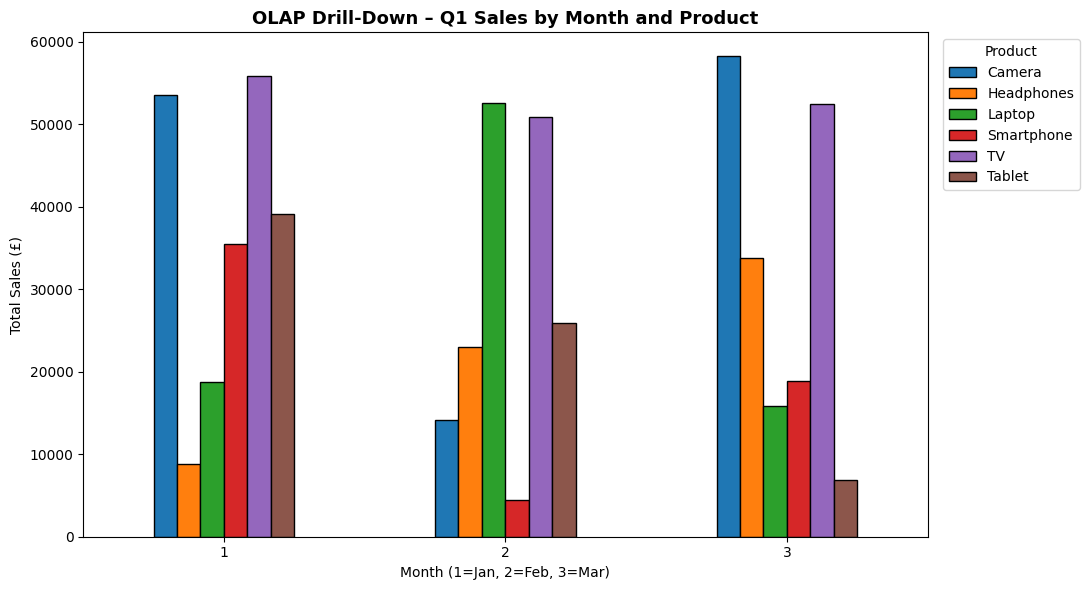

In [18]:
pivot.plot(kind='bar', figsize=(11, 6), edgecolor='black')
plt.title('OLAP Drill-Down – Q1 Sales by Month and Product', fontsize=13, fontweight='bold')
plt.ylabel('Total Sales (£)'); plt.xlabel('Month (1=Jan, 2=Feb, 3=Mar)')
plt.xticks(rotation=0)
plt.legend(title='Product', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('drill_down.png', dpi=150)
plt.show()

In [19]:
cuboid1 = df_merged.groupby(['city','product'])['total_sales'].sum().unstack(fill_value=0)
cuboid2 = df_merged.groupby(['city','season'])['total_sales'].sum().unstack(fill_value=0)
cuboid3 = df_merged.groupby(['product','season'])['total_sales'].sum().unstack(fill_value=0)

print("Cuboid 1 – City × Product:\n", cuboid1)
print("\nCuboid 2 – City × Season:\n", cuboid2)
print("\nCuboid 3 – Product × Season:\n", cuboid3)

Cuboid 1 – City × Product:
 product        Camera  Headphones    Laptop  Smartphone         TV     Tablet
city                                                                         
Birmingham   41465.29    73483.04  88805.45   103756.46  116563.29   80070.16
Bristol      85536.87    99003.20  98618.97    23858.27  121973.29   70541.08
Edinburgh    99027.07    85715.06  95356.98    60450.97  112829.95   32892.60
London       82703.22    93801.83  66500.11    87864.02   76230.69   79945.37
Manchester  110513.27    53937.77  96455.30   109360.05  105346.75  119868.90

Cuboid 2 – City × Season:
 season             Q1         Q2         Q3         Q4
city                                                  
Birmingham   66785.83  174376.62  192598.26   70382.98
Bristol     130981.25  124898.08   96111.03  147541.32
Edinburgh    79036.51  109725.38  120948.07  176562.67
London      173982.95  107912.99   80602.83  124546.47
Manchester  117940.84  182161.71  167185.18  128194.31

Cuboid 3 – P

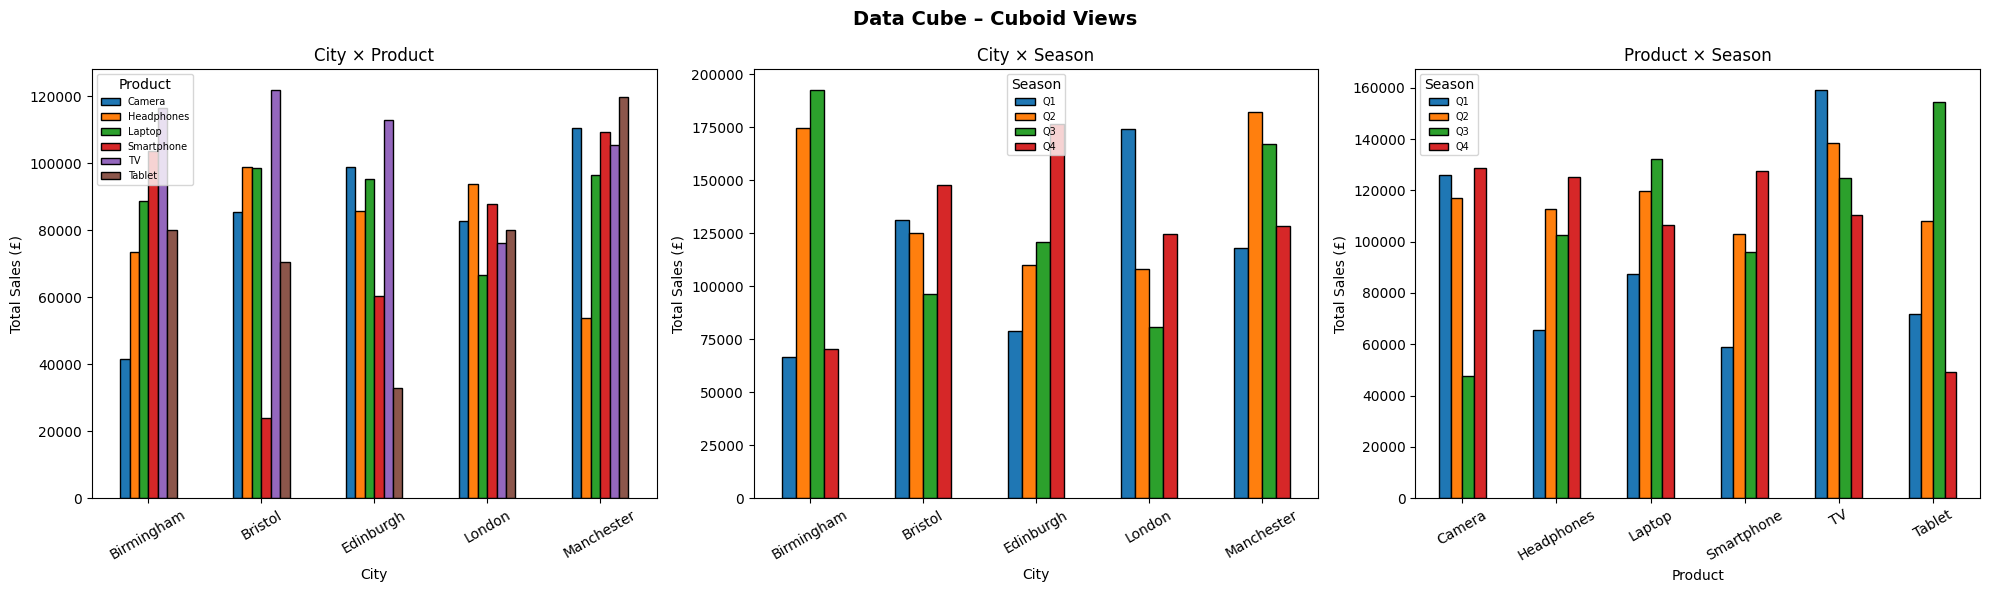

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Data Cube – Cuboid Views', fontsize=14, fontweight='bold')

cuboid1.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('City × Product'); axes[0].set_xlabel('City')
axes[0].set_ylabel('Total Sales (£)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Product', fontsize=7)

cuboid2.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('City × Season'); axes[1].set_xlabel('City')
axes[1].set_ylabel('Total Sales (£)'); axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Season', fontsize=7)

cuboid3.plot(kind='bar', ax=axes[2], edgecolor='black')
axes[2].set_title('Product × Season'); axes[2].set_xlabel('Product')
axes[2].set_ylabel('Total Sales (£)'); axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title='Season', fontsize=7)

plt.tight_layout()
plt.savefig('cube_cuboids.png', dpi=150)
plt.show()

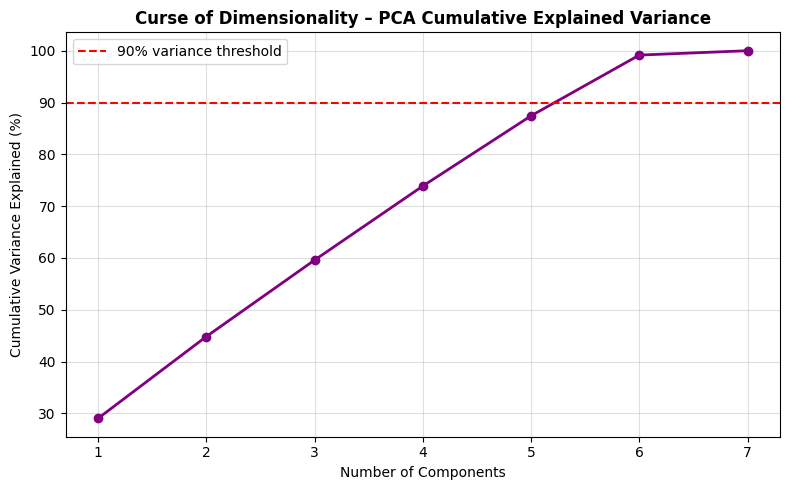

Variance per component (%): [29.05 15.79 14.76 14.29 13.55 11.72  0.84]


In [21]:
df_pca = df_merged[['product','city','season','age','quantity','unit_price','total_sales']].copy()
for col in ['product','city','season']:
    df_pca[col] = LabelEncoder().fit_transform(df_pca[col].astype(str))
df_pca = df_pca.dropna()

scaled = StandardScaler().fit_transform(df_pca)
pca = PCA()
pca.fit(scaled)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_)*100, marker='o', color='purple', linewidth=2)
plt.axhline(90, color='red', linestyle='--', label='90% variance threshold')
plt.title('Curse of Dimensionality – PCA Cumulative Explained Variance', fontsize=12, fontweight='bold')
plt.xlabel('Number of Components'); plt.ylabel('Cumulative Variance Explained (%)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout()
plt.show()

print("Variance per component (%):", np.round(pca.explained_variance_ratio_*100, 2))